# Band gaps from the Tran-Blaha potential

A semilocal functional underestimates the band gap, and it does so by about a factor of two.
Silicon's is 1.17 eV; LDA gives 0.5. The usual fixes, a hybrid functional or $GW$, cost one
or two orders of magnitude more than the SCF they correct.

**Tran and Blaha's modified Becke-Johnson potential** ([Phys. Rev. Lett. **102**, 226401
(2009)](https://doi.org/10.1103/PhysRevLett.102.226401)) gets most of the gap back for the
price of a gradient-corrected functional. It is written down as a *potential*:

$$v_{x,\sigma}^{\mathrm{mBJ}}(\mathbf r) = c\,v_{x,\sigma}^{\mathrm{BR}}(\mathbf r)
  + (3c-2)\,\frac{1}{\pi}\sqrt{\frac{5}{12}}\,
    \sqrt{\frac{2\tau_\sigma(\mathbf r)}{\rho_\sigma(\mathbf r)}},
\qquad
c = \alpha + \beta\left[\frac{1}{V_{\rm cell}}\int_{\rm cell}
     \frac{|\nabla\rho|}{\rho}\,\mathrm d^3r'\right]^{1/2}$$

with $\alpha = -0.012$, $\beta = 1.023\,a_0^{1/2}$, and $v_x^{\rm BR}$ the Becke-Roussel
model of the exchange hole. $c = 1$ recovers Becke-Johnson.

Two things follow from it being a potential and not the derivative of an energy. The total
energy is **not variational**, so forces, stress, phonons and linear response are refused;
the eigenvalues are the point. And the coefficient $c$ is an average over the whole cell, so
the potential at one point depends on the density everywhere, which is unlike every other
functional here. The SCF also carries a second field, the kinetic energy density $\tau$,
which comes from the states rather than from the density.

`pw.x` cannot compute this. It reaches TB09 only through libxc, and then passes a zero
Laplacian and never sets $c$, so what it runs under that name is Becke-Johnson.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io.pwin import Card, read_pw_input
from pypresso.pseudo import read_upf
from pypresso.system import build_system
from pypresso.system.kpoints import KPoints
from pypresso.units import RY_TO_EV
from pypresso.workflows import run_bands
from pypresso.xc.functional import get_functional

CASES = Path("..") / "quantum_espresso" / "qe-7.5-ReleasePack" / "qe-7.5" / "test-suite"
PSEUDO = Path("..") / "tests" / "data" / "pseudo"


def silicon(dft=None, ecutwfc=30.0, grid=(6, 6, 6)):
    # QE's own two-atom silicon, at a converged cutoff and an automatic k-grid.
    data = read_pw_input(CASES / "pw_scf" / "scf.in")
    data.namelists["system"].update(ecutwfc=ecutwfc, input_dft=dft)
    data.cards["K_POINTS"] = Card("K_POINTS", "automatic",
                                  (f"{grid[0]} {grid[1]} {grid[2]} 0 0 0",))
    system = build_system(data)
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return Calculator(system, pseudos, announce=False, nbnd=10, conv_thr=1e-9)


functional = get_functional("tb09")
print(f"name = {functional.name}   is_meta = {functional.is_meta}   "
      f"c = {functional.meta_coefficient}  (None means: average it over the cell)")
print(f"exchange slot = {functional.exchange.__name__}   "
      f"correlation slot = {functional.correlation.__name__}")

name = TB09   is_meta = True   c = None  (None means: average it over the cell)
exchange slot = no_exchange   correlation slot = pw_correlation


## 1. Two analytic limits pin the functional

There is no reference calculation to compare against, so the validation is against limits
the model satisfies exactly.

**The hydrogen atom.** For a one-orbital density the quantity
$D_\sigma = 2\tau_\sigma - |\nabla\rho_\sigma|^2/4\rho_\sigma$ vanishes identically, and
Becke-Roussel collapses onto the *exact* Slater potential of the 1s orbital. That fixes the
sign conventions, the branch of the nonlinear solve and the prefactor all at once, and
$E_x$ comes out at exactly $-5/16$ Ha.

**The uniform gas.** Becke-Johnson's $\sqrt{5/12}/\pi$ is chosen so that $v_x^{\rm BJ}$
reproduces $v_x^{\rm LDA}$ there. It does, to 6e-4, and that residue is the Becke-Roussel
model's own error rather than a numerical one.

In [2]:
import jax.numpy as jnp

from pypresso.units import E2
from pypresso.xc.mgga import becke_roussel_potential_hartree, tb09_potential

# hydrogen 1s: rho = e^{-2r}/pi, one electron in one spin channel
r = np.linspace(1e-4, 6.0, 4001)
rho = np.exp(-2 * r) / np.pi
model = np.asarray(becke_roussel_potential_hartree(
    jnp.asarray(rho), jnp.asarray((2 * rho) ** 2),
    jnp.asarray((4 - 4 / r) * rho), jnp.asarray(rho / 2),
))
exact = -(1 / r) * (1 - (1 + r) * np.exp(-2 * r))
print(f"hydrogen 1s:  max |v_BR - v_Slater| = {np.abs(model - exact).max():.2e} Ha")

# uniform gas: c = 1 must give back the LDA exchange potential
for n in (0.01, 1.0, 50.0):
    tau = 0.3 * (6 * np.pi**2) ** (2 / 3) * n ** (5 / 3)
    v = float(tb09_potential(jnp.asarray(n), jnp.asarray(0.0),
                             jnp.asarray(0.0), jnp.asarray(tau), 1.0)) / E2
    lda = -((6 * n / np.pi) ** (1 / 3))
    print(f"uniform gas rho_s = {n:5.2f}:  v_BJ = {v:9.6f}   v_LDA = {lda:9.6f}   "
          f"rel = {abs(v - lda) / abs(lda):.2e}")

hydrogen 1s:  max |v_BR - v_Slater| = 1.11e-13 Ha
uniform gas rho_s =  0.01:  v_BJ = -0.267141   v_LDA = -0.267301   rel = 6.00e-04


uniform gas rho_s =  1.00:  v_BJ = -1.239957   v_LDA = -1.240701   rel = 6.00e-04
uniform gas rho_s = 50.00:  v_BJ = -4.568041   v_LDA = -4.570781   rel = 6.00e-04


## 2. Two SCF runs, and the coefficient the second one measures

`input_dft = 'tb09'` is the only thing that changes. The run announces that its total energy
is not variational, takes about twice the iterations LDA takes, and reports the $c$ it
settled on, which moves with the density and is therefore part of what has to converge.

In [3]:
import warnings

results = {}
for label, dft in (("LDA (PZ)", None), ("TB09", "tb09"), ("BJ06 (c = 1)", "bj06")):
    calc = silicon(dft)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        results[label] = calc
        calc.get_scf(max_iterations=90, tstress=False)

for label, calc in results.items():
    scf = calc.scf_result
    c = "    -    " if scf.meta_c is None else f"{scf.meta_c:9.5f}"
    print(f"{label:14s}  {scf.iterations:3d} iterations   c = {c}   "
          f"E = {scf.total_energy:14.8f} Ry")
print("\nThe three energies are NOT comparable with each other: two of them have no"
      "\nexchange energy at all, only the correlation half of etxc.")

LDA (PZ)          6 iterations   c =     -       E =   -15.85056061 Ry
TB09             10 iterations   c =   1.03310   E =   -11.71980109 Ry
BJ06 (c = 1)     11 iterations   c =   1.00000   E =   -11.73397051 Ry

The three energies are NOT comparable with each other: two of them have no
exchange energy at all, only the correlation half of etxc.


## 3. The figure: the same bands, twice

The valence bands are almost untouched, because the potential corrects *exchange* and the
occupied manifold is what the density constrains. The conduction bands move up nearly
rigidly, which is the mechanism in one picture: mBJ acts like a scissor operator whose size
the density itself sets, rather than one applied by hand.

/u/40/ladovj1/data/Documents/programs/claude/pypresso/pypresso/scf/driver.py:804: UserWarning: input_dft asks for TB09 but the pseudopotentials were generated with PZ; running them together is inconsistent, as it is in QE
  self.functional = resolve_functional(


/u/40/ladovj1/data/Documents/programs/claude/pypresso/pypresso/scf/driver.py:804: UserWarning: input_dft asks for BJ06 but the pseudopotentials were generated with PZ; running them together is inconsistent, as it is in QE
  self.functional = resolve_functional(


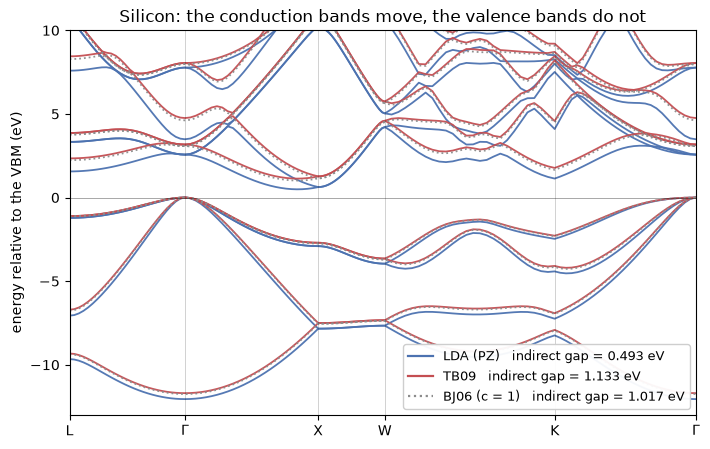

In [4]:
FCC = {"L": (.5, .5, .5), "G": (0., 0., 0.), "X": (0., 0., 1.),
       "W": (.5, 0., 1.), "K": (.75, .75, 0.)}
PATH = ["L", "G", "X", "W", "K", "G"]
NOCC = 4

COUNTS = [25] * (len(PATH) - 1) + [1]
kpath = KPoints.band_path([FCC[p] for p in PATH], COUNTS,
                          results["LDA (PZ)"].system.cell, crystal=False)

bands, gaps = {}, {}
for label, calc in results.items():
    # `tau` is a property of the states, not of the density, so a meta-GGA band
    # path needs it as well -- and the calculator carries it across.
    b = calc.get_bands(kpoints=kpath)
    ev = np.asarray(b.eigenvalues) * RY_TO_EV
    ev = ev - ev[:, :NOCC].max()                   # valence-band maximum at zero
    bands[label] = ev
    gaps[label] = (ev[:, NOCC:].min(),
                   (ev[:, NOCC:].min(axis=1) - ev[:, :NOCC].max(axis=1)).min())

x = np.asarray(kpath.path_length)
# Each segment contributes ``COUNTS[i]`` points, so the high-symmetry vertices
# sit at the running sum of the counts. There are no repeated path lengths to
# find them by: no segment on this path has zero length.
edges = x[np.cumsum([0] + COUNTS[:-1])]
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for label, colour, style in (("LDA (PZ)", "#4c72b0", "-"),
                             ("TB09", "#c44e52", "-"),
                             ("BJ06 (c = 1)", "#8c8c8c", ":")):
    ax.plot(x, bands[label], style, color=colour, lw=1.3, alpha=0.95)
    ax.plot([], [], style, color=colour, lw=1.6,
            label=f"{label}   indirect gap = {gaps[label][0]:.3f} eV")
ax.axhline(0.0, color="k", lw=0.6, alpha=0.4)
for edge in edges[1:-1]:
    ax.axvline(edge, color="k", lw=0.5, alpha=0.25)
ax.set_xticks(edges)
ax.set_xticklabels([p if p != "G" else r"$\Gamma$" for p in PATH])
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-13, 10)
ax.set_ylabel("energy relative to the VBM (eV)")
ax.set_title("Silicon: the conduction bands move, the valence bands do not")
ax.legend(loc="lower right", fontsize=9, framealpha=0.95)
fig.tight_layout()

## 4. Against experiment

The number to compare is the **indirect** gap, $\Gamma_{25'} \to \Delta_{\rm min}$.

In [5]:
EXPERIMENT = {"indirect": 1.17, "direct": 3.40}
PUBLISHED_MBJ = 1.17   # Tran & Blaha 2009, WIEN2k all-electron, c = 1.12

print(f"{'':16s}{'indirect (eV)':>15s}{'direct (eV)':>14s}")
for label in results:
    print(f"{label:16s}{gaps[label][0]:15.3f}{gaps[label][1]:14.3f}")
print(f"{'experiment':16s}{EXPERIMENT['indirect']:15.3f}{EXPERIMENT['direct']:14.3f}")
print(f"\npublished all-electron mBJ (c = 1.12): {PUBLISHED_MBJ:.2f} eV")
print(f"this run's c: {results['TB09'].scf_result.meta_c:.4f}   "
      f"(a pseudopotential has no core, and the core is where |grad rho|/rho is largest)")

                  indirect (eV)   direct (eV)
LDA (PZ)                  0.493         2.567
TB09                      1.133         3.168
BJ06 (c = 1)              1.017         3.075
experiment                1.170         3.400

published all-electron mBJ (c = 1.12): 1.17 eV
this run's c: 1.0331   (a pseudopotential has no core, and the core is where |grad rho|/rho is largest)


**Where the remaining shortfall comes from.** The coefficient $c$ averages
$|\nabla\rho|/\rho$ over the cell, and that ratio is largest *in the core*, which a
pseudopotential has removed. Norm-conserving silicon gives $c = 1.033$ where an all-electron
calculation gives 1.12, and the gap grows steadily with $c$. `mbj_c` imposes a value, as
WIEN2k and VASP allow. Measured once, offline, on this cell:

| `mbj_c` | | indirect gap (eV) | SCF iterations |
|---|---|---|---|
| 1.000 | (Becke-Johnson) | 1.018 | 11 |
| 1.033 | (self-consistent, this pseudopotential) | **1.134** | 10 |
| 1.120 | (the all-electron value of the 2009 paper) | 1.455 | 21 |
| 1.200 | | 1.776 | 23 |
| 1.300 | | 2.215 | 24 |

At the all-electron $c$ this cell *overshoots*, which says the pseudopotential's $c$ and its
density are not two independent errors: what the core removed is missing from $\tau$ and
from the Laplacian as well as from $c$, and imposing one without the others is not a
correction. **PAW recovers most of it**, because its partial waves reconstruct $\tau$ inside
the sphere: $c$ comes out at 1.107 against the all-electron 1.12, where norm-conserving
silicon measures 1.000.

Diamond shows the other half of the story: its $c$ comes out at 1.178, its gap goes from
LDA's 3.89 eV to 4.43 eV, and it stays about 0.5 eV under the all-electron mBJ at any $c$
near the measured one. It is not a basis-set artefact, since raising the cutoff from 60 to
90 Ry moves the gaps by 0.03 eV.

**One thing to watch when reading eigenvalues.** The *highest* band of an `nbnd` window does
not converge under this functional the way it does under LDA, because mBJ's potential mixes
that band with the ones just outside the window far more than a local potential does. The
density does not care, so ask for a few more bands than you intend to read.

## 5. Does it converge?

$\tau$ lags the density by one iteration and $c$ couples every grid point to every other,
which are both reasons to expect trouble. Measured on this cell, in evaluations of the SCF
map:

| | LDA | TB09 |
|---|---|---|
| Anderson mixing, $\beta = 0.7$ | 6 | 11 |
| Anderson mixing, $\beta = 0.3$ | 7 | 19 |
| Newton-Krylov on the residual | 40 | 75 |
| Newton-Krylov after 3 mixing steps | 17 | 59 |

Mixing wins, and the exact Jacobian does not pay for itself: TB09's fixed point is not badly
enough conditioned to be worth several inner solves per step. What the functional does cost
is a factor of about **1.8 in iterations** over LDA, growing with $c$.

---
The tests behind this notebook: `tests/unit/test_mgga.py` (the analytic limits) and
`tests/regression/test_mbj.py` (the two spin regimes, the gap, and the refusals).

Refused: plain ultrasoft, which has no partial waves to reconstruct $\tau$ from inside the
sphere where PAW has them; spin spirals; a Hubbard `U`; and every derivative of the total
energy, since it is not the value of a functional. **PAW works**, and so does noncollinear
magnetism with **spin-orbit coupling**, both of which `pw.x` refuses outright.